In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np

In [3]:
df = pd.read_excel("/home/jpkrowe/projects/Yixuan_diamon_05-2026/DPeriod_Skewed_5511.xlsx")

In [10]:
# all_scans = glob.glob("/home/jpkrowe/projects/Yixuan_diamon_05-2026/radiationtest/*.xlsx")
all_scans = glob.glob("/home/jpkrowe/projects/Yixuan_diamon_05-2026/DPeriod*.xlsx")

In [16]:
dfs = {scan_no + 1: pd.read_excel(scan) for scan_no, scan in enumerate(all_scans)}

/tmp/ipykernel_37288/301620480.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


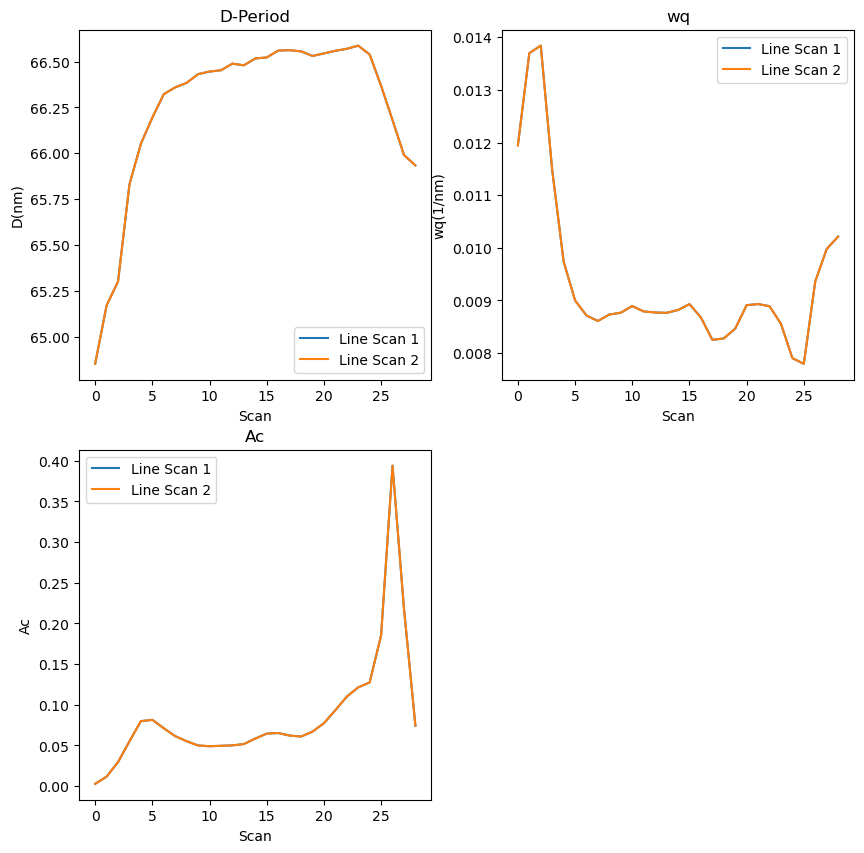

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(221)
for scan_no, df in dfs.items():
    ax.plot(df["Scan"], df["D(nm)"], label=f"Line Scan {scan_no}")
ax.set_xlabel("Scan")
ax.set_ylabel("D(nm)")
ax.set_title("D-Period")
ax.legend()

ax2 = fig.add_subplot(222)
for  scan_no, df in dfs.items():
    ax2.plot(df["Scan"], df["wq(1/nm)"], label=f"Line Scan {scan_no}")
ax2.set_xlabel("Scan")
ax2.set_ylabel("wq(1/nm)")
ax2.set_title("wq")
ax2.legend()

ax3 = fig.add_subplot(223)
for scan_no, df in dfs.items():
    ax3.plot(df["Scan"], df["Ac"], label=f"Line Scan {scan_no}")
ax3.set_xlabel("Scan")
ax3.set_ylabel("Ac")
ax3.set_title("Ac")
ax3.legend()

fig.show()

/tmp/ipykernel_37288/2441783203.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


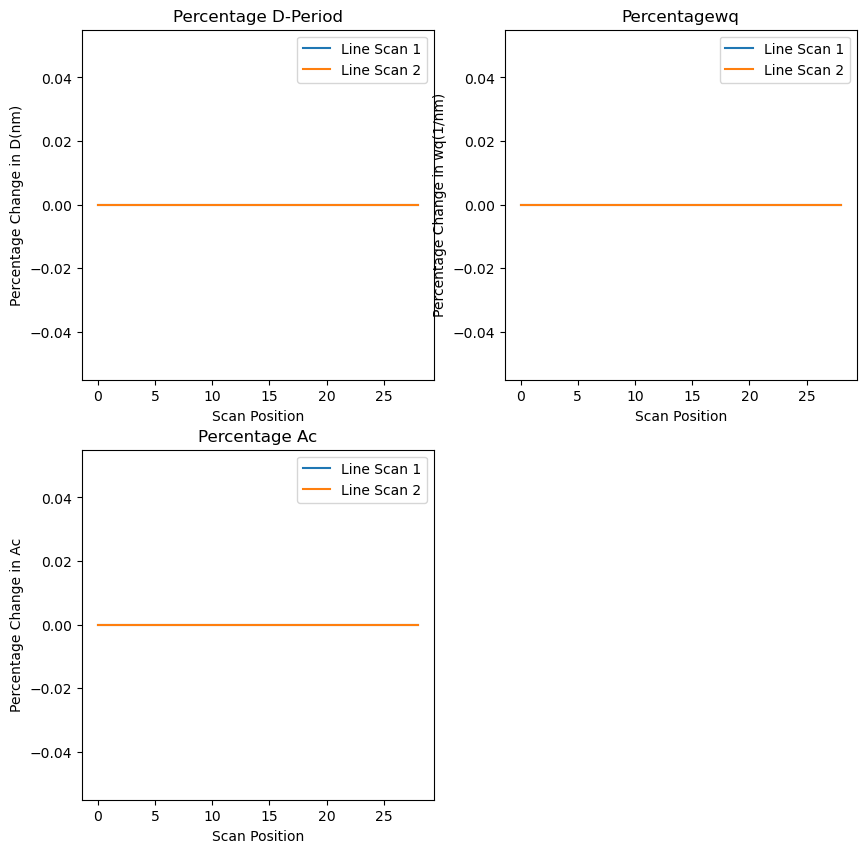

In [27]:
ref_scan = dfs[1]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(221)
for scan_no, df in dfs.items():
    ax.plot(df["Scan"], (df["D(nm)"] - ref_scan["D(nm)"])/ref_scan["D(nm)"]*100, label=f"Line Scan {scan_no}")
ax.set_xlabel("Scan Position")
ax.set_ylabel("Percentage Change in D(nm)")
ax.set_title("Percentage D-Period")
ax.legend()

ax2 = fig.add_subplot(222)
for  scan_no, df in dfs.items():
    ax2.plot(df["Scan"], (df["wq(1/nm)"] - ref_scan["wq(1/nm)"])/ref_scan["wq(1/nm)"]*100, label=f"Line Scan {scan_no}")
ax2.set_xlabel("Scan Position")
ax2.set_ylabel("Percentage Change in wq(1/nm)")
ax2.set_title("Percentagewq")
ax2.legend()

ax3 = fig.add_subplot(223)
for scan_no, df in dfs.items():
    ax3.plot(df["Scan"], (df["Ac"] - ref_scan["Ac"])/ref_scan["Ac"]*100, label=f"Line Scan {scan_no}")
ax3.set_xlabel("Scan Position")
ax3.set_ylabel("Percentage Change in Ac")
ax3.set_title("Percentage Ac")
ax3.legend()

fig.show()

/tmp/ipykernel_37288/1857517118.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_diff.show()


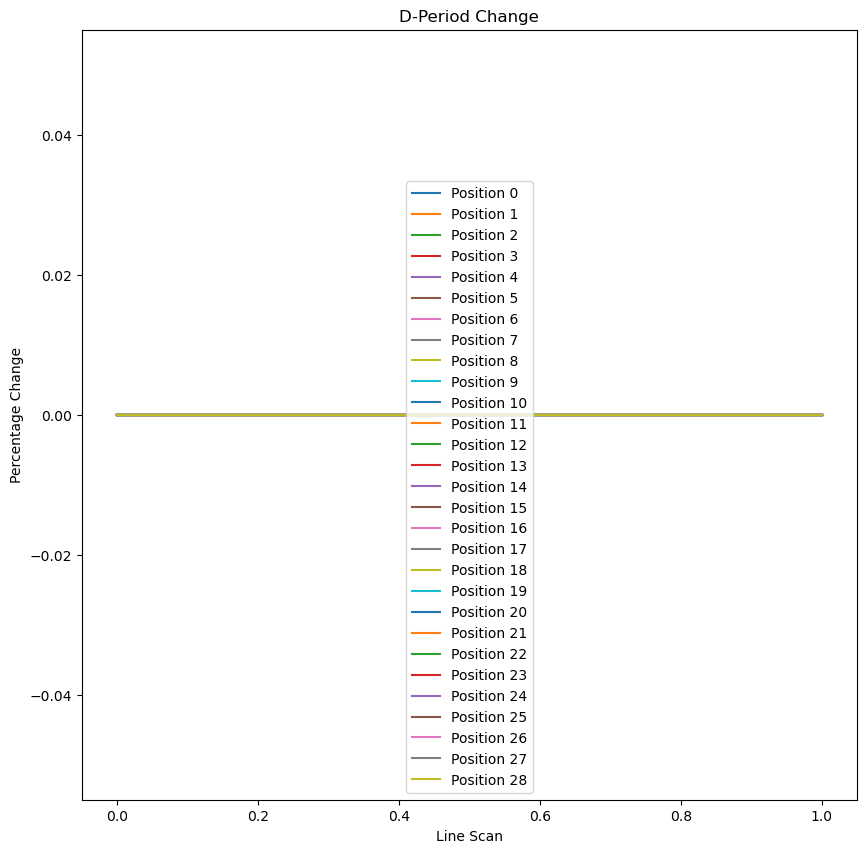

In [25]:
ref_scan = dfs[1]

diffs = np.vstack([(df["D(nm)"] - ref_scan["D(nm)"])/ref_scan["D(nm)"]*100 for scan_no, df in dfs.items() if scan_no != 0])

fig_diff = plt.figure(figsize=(10, 10))
ax_diff = fig_diff.add_subplot(111)

for scan_pos, diff in enumerate(diffs.T):
    ax_diff.plot(diff, label=f"Position {ref_scan['Scan'][scan_pos]}")
ax_diff.set_xlabel("Line Scan")
ax_diff.set_ylabel("Percentage Change")
ax_diff.set_title("D-Period Change")
ax_diff.legend()

fig_diff.show()